In [13]:
# =========================
# STEP 1: AGGREGATE DATA
# =========================

import pandas as pd

df = pd.read_csv('../perf_metrics.csv')

# Drop process-level identifiers
df = df.drop(columns=['pid', 'comm'])

# Create 1-second time windows
# Create artificial time windows using row index
window_size = 200   # <-- tune this later

df = df.reset_index(drop=True)
df['time_window'] = df.index // window_size

# Aggregate all numeric features
agg_dict = {}

for col in df.columns:
    if col not in ['label', 'time_window', 'timestamp_s']:
        agg_dict[col] = 'sum'

df_agg = df.groupby('time_window').agg(agg_dict)

# Assign label = most frequent label in that time window
df_agg['label'] = df.groupby('time_window')['label'].agg(lambda x: x.mode()[0])

df_agg = df_agg.reset_index(drop=True)
df = df.drop(columns=['timestamp_s'])
print("Aggregated shape:", df_agg.shape)
print(df_agg['label'].value_counts())

Aggregated shape: (510, 38)
label
io_bound        161
memory_bound     89
contention       80
cpu_bound        75
normal_light     40
normal_idle      37
normal_mixed     28
Name: count, dtype: int64



=== CORRELATION MATRIX (TOP PAIRS > 0.85) ===
=== RANDOM FOREST ===
              precision    recall  f1-score   support

  contention       0.93      0.88      0.90        16
   cpu_bound       0.88      0.93      0.90        15
    io_bound       1.00      0.97      0.98        32
memory_bound       0.90      1.00      0.95        18
      normal       1.00      0.95      0.98        21

    accuracy                           0.95       102
   macro avg       0.94      0.95      0.94       102
weighted avg       0.95      0.95      0.95       102


=== XGBOOST ===
              precision    recall  f1-score   support

  contention       0.94      1.00      0.97        16
   cpu_bound       1.00      0.93      0.97        15
    io_bound       1.00      0.94      0.97        32
memory_bound       0.82      1.00      0.90        18
      normal       1.00      0.90      0.95        21

    accuracy                           0.95       102
   macro avg       0.95      0.96      0.95  

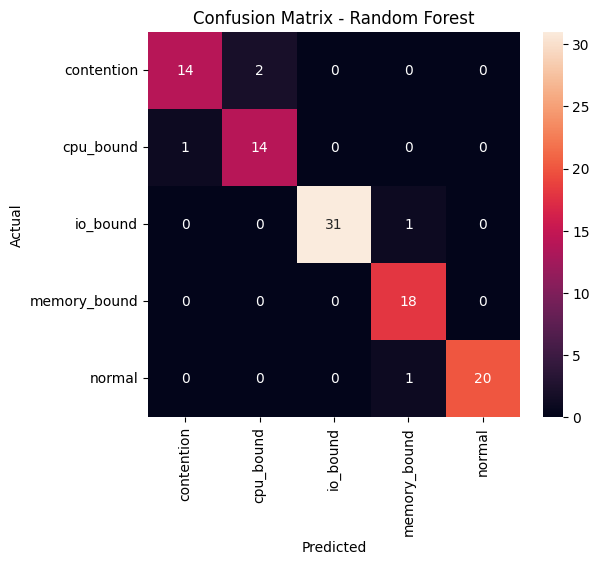


=== CROSS VALIDATION (STRATIFIED SHUFFLED) ===
Scores: [0.94117647 0.91176471 0.89215686 0.95098039 0.95098039]
Mean: 0.9294117647058824
Std: 0.02352941176470585


In [14]:
# =========================
# FULL PIPELINE (ONE CELL)
# =========================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

# -------- LOAD --------
df = df = df_agg.copy()

# -------- DROP IDENTIFIERS --------
# df = df.drop(columns=['timestamp_s', 'pid', 'comm'])

# -------- DROP LOW VARIANCE --------
if 'total_free_bytes' in df.columns:
    df = df.drop(columns=['total_free_bytes'])

# -------- DROP HIGHLY CORRELATED FEATURES --------
df = df.drop(columns=[
    'involuntary_switches',
    'kmalloc_count',
    'kfree_count',
    'minor_faults',
    'large_page_allocs',
    'write_count',
    'rwsem_read_contentions'
], errors='ignore')

# -------- DROP SPARSE FEATURES --------
drop_sparse = [
    'cpu_migrations',
    'avg_rwsem_read_wait_ns',
    'rwsem_write_contentions',
    'avg_rwsem_write_wait_ns',
    'max_rwsem_write_wait_ns',
    'avg_mutex_wait_ns',
    'mutex_contentions',
    'max_mutex_wait_ns',
    'poll_count',
    'epoll_count',
    'avg_epoll_latency_ns',
    'kernel_faults',
    'mmap_count',
    'syscall_error_count'
]

df = df.drop(columns=drop_sparse, errors='ignore')

# -------- MERGE LABELS --------
df['label'] = df['label'].replace({
    'normal_idle': 'normal',
    'normal_light': 'normal',
    'normal_mixed': 'normal'
})

# -------- SPLIT FEATURES --------
X = df.drop(columns=['label'])
y = df['label']

# -------- DERIVED FEATURES --------
X['runtime_per_switch'] = X['total_runtime_ns'] / (X['ctx_switches'] + 1)
X['io_intensity'] = (X['read_bytes'] + X['write_bytes']) / (X['total_runtime_ns'] + 1)
X['syscall_intensity'] = X['syscall_count'] / (X['total_runtime_ns'] + 1)
# -------- REPLACE IO FEATURES --------
X['total_io_bytes'] = X['read_bytes'] + X['write_bytes']

X = X.drop(columns=['read_bytes', 'write_bytes'], errors='ignore')
# -------- DROP CORRELATED FEATURES (FINAL CLEANUP) --------
X = X.drop(columns=['avg_runq_latency_ns'], errors='ignore')
# -------- DROP CPU ID (not meaningful for model) --------
X = X.drop(columns=['cpu'], errors='ignore')
drop_low_importance = [
    'avg_futex_latency_ns'
]

X = X.drop(columns=drop_low_importance, errors='ignore')
# =========================
# CORRELATION ANALYSIS
# =========================

corr = pd.DataFrame(X).corr()

print("\n=== CORRELATION MATRIX (TOP PAIRS > 0.85) ===")

high_corr = []
for i in corr.columns:
    for j in corr.columns:
        if i < j and abs(corr.loc[i, j]) > 0.85:
            high_corr.append((i, j, corr.loc[i, j]))

# sort by strength
high_corr = sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)

for pair in high_corr[:20]:
    print(pair)

# Optional: full matrix (only if you want)
# print(corr)
# -------- LOG TRANSFORM --------
X = np.log1p(X)

# -------- SCALING --------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------- ENCODE LABELS --------
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# -------- TRAIN TEST SPLIT --------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# =========================
# RANDOM FOREST
# =========================
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== RANDOM FOREST ===")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

# =========================
# XGBOOST
# =========================
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("\n=== XGBOOST ===")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

# =========================
# FEATURE IMPORTANCE (RF)
# =========================
importances = pd.Series(rf.feature_importances_, index=X.columns)
print("\n=== TOP FEATURES (RF) ===")
print(importances.sort_values(ascending=False).head(10))

rf_pred = rf.predict(X_test)

# =========================
# CONFUSION MATRIX (RF)
# =========================
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# CROSS VALIDATION
# =========================
from sklearn.model_selection import cross_val_score

# =========================
# CROSS VALIDATION (FIXED)
# =========================
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf, X_scaled, y_encoded, cv=cv)

print("\n=== CROSS VALIDATION (STRATIFIED SHUFFLED) ===")
print("Scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

In [15]:
import joblib
print("Train accuracy:", rf.score(X_train, y_train))
print("Test accuracy:", rf.score(X_test, y_test))


joblib.dump(rf, "rf_model.pkl")
joblib.dump(le, "label_encoder.pkl")

Train accuracy: 1.0
Test accuracy: 0.9509803921568627


['label_encoder.pkl']

In [16]:
def predict_sample(sample):
    sample = np.log1p(sample)
    sample = scaler.transform([sample])
    pred = rf.predict(sample)
    return le.inverse_transform(pred)[0]

deeplearning


In [ ]:
# =========================
# DEEP LEARNING MODEL (IMPROVED)
# =========================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(len(le.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# -------- EVALUATION --------
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("\n=== DEEP LEARNING ===")
print("Test Accuracy:", acc)

Epoch 1/50


C:\Users\asad0\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3344 - loss: 1.5374 - val_accuracy: 0.5000 - val_loss: 1.3278
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5706 - loss: 1.2077 - val_accuracy: 0.5732 - val_loss: 1.1575
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6626 - loss: 1.0159 - val_accuracy: 0.6585 - val_loss: 1.0105
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7025 - loss: 0.9155 - val_accuracy: 0.7073 - val_loss: 0.9005
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7485 - loss: 0.7863 - val_accuracy: 0.7317 - val_loss: 0.8332
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7945 - loss: 0.6931 - val_accuracy: 0.7317 - val_loss: 0.7523
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7883 - loss: 0.6550 - val_accuracy: 0.7439 - val_loss: 0.7028
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8067 - loss: 0.5605 - val_accuracy: 0.7683 - val_loss: 0.6413
Epo